In [43]:
import os
import shutil

print("📁 Current folder contents:")
print(os.listdir('.'))

print("\n📁 data/ folder contents:")
print(os.listdir('data'))

📁 Current folder contents:
['.ipynb_checkpoints', '01_data_cleaning_eda.ipynb', 'anaconda_projects', 'dashboards', 'data', 'desktop.ini', 'notebook', 'owid-covid-data.csv', 'visuals']

📁 data/ folder contents:
['owid-covid-data.csv']


In [44]:
import shutil
shutil.copy('owid-covid-data.csv', 'data/owid-covid-data.csv')
print("✅ Done!")
print("data/ now contains:", os.listdir('data'))

✅ Done!
data/ now contains: ['owid-covid-data.csv']


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

In [46]:
df = pd.read_csv('data/owid-covid-data.csv')
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (429435, 67)

Columns:
 ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_v

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [47]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== NULL % PER COLUMN (top 20) ===")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct.head(20))

=== DATA TYPES ===
iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
population                                   int64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object

=== NULL % PER COLUMN (top 20) ===
weekly_icu_admissions_per_million          97.440125
weekly_icu_admissions                      97.440125
excess_mortality_cumulative_per_million    96.877059
excess_mortality                           96.877059
excess_mortality_cumulative                96.877059
excess_mortality_cumulative_absolute       96.877059
weekly_hosp_admissions_per_million      

In [48]:

df['date'] = pd.to_datetime(df['date'])

# Drop aggregate non-country rows (continents, income groups, World)
non_countries = df[df['iso_code'].str.startswith('OWID', na=False)]['location'].unique()
print("Removing non-country entries:", non_countries)
df = df[~df['iso_code'].str.startswith('OWID', na=False)]

# Keep key columns
key_cols = [
    'iso_code', 'continent', 'location', 'date',
    'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
    'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated',
    'population', 'gdp_per_capita', 'life_expectancy',
    'total_cases_per_million', 'total_deaths_per_million',
    'new_cases_smoothed', 'new_deaths_smoothed',
    'hospital_beds_per_thousand', 'human_development_index'
]
df = df[key_cols]

# Fill numeric nulls forward within each country, then backfill
df = df.sort_values(['location', 'date'])
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df.groupby('location')[numeric_cols].transform(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
)
df[numeric_cols] = df[numeric_cols].fillna(0)

print("\nCleaned shape:", df.shape)
print("Date range:", df['date'].min(), "→", df['date'].max())
df.head()

Removing non-country entries: ['Africa' 'Asia' 'England' 'Europe' 'European Union (27)'
 'High-income countries' 'Kosovo' 'Low-income countries'
 'Lower-middle-income countries' 'North America' 'Northern Cyprus'
 'Northern Ireland' 'Oceania' 'Scotland' 'South America'
 'Upper-middle-income countries' 'Wales' 'World']

Cleaned shape: (395311, 20)
Date range: 2020-01-01 00:00:00 → 2024-08-14 00:00:00


,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_vaccinated,people_fully_vaccinated,population,gdp_per_capita,life_expectancy,total_cases_per_million,total_deaths_per_million,new_cases_smoothed,new_deaths_smoothed,hospital_beds_per_thousand,human_development_index
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51


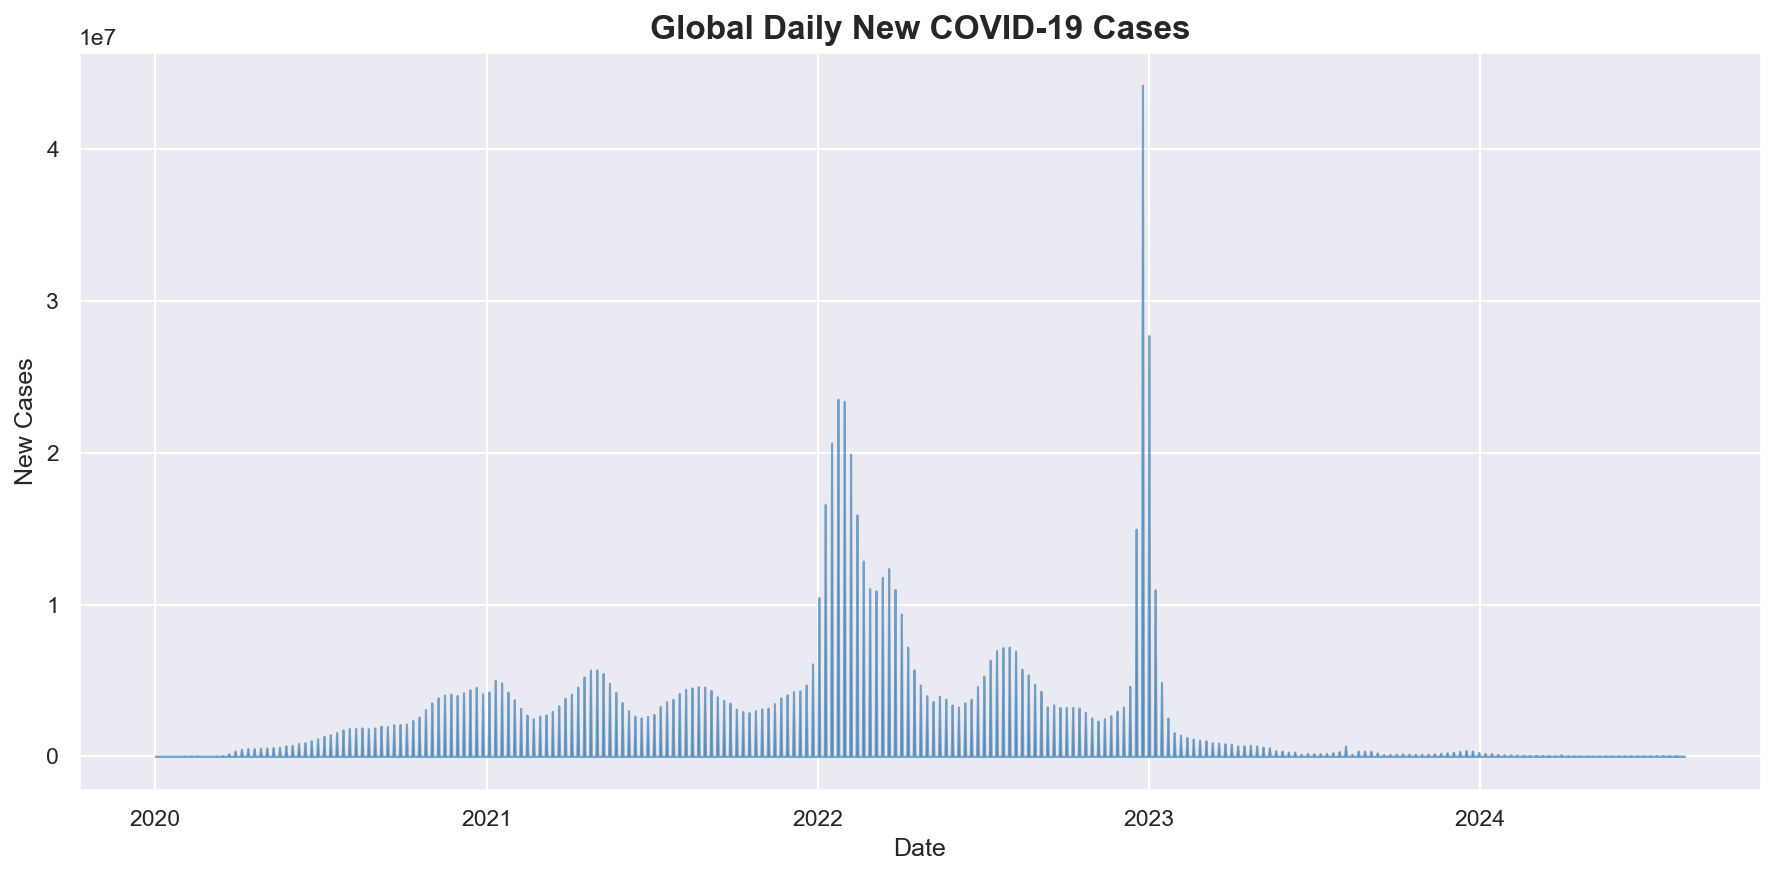

✅ Saved chart1


In [49]:
os.makedirs('visuals', exist_ok=True)

global_daily = df.groupby('date')['new_cases'].sum().reset_index()

fig, ax = plt.subplots()
ax.fill_between(global_daily['date'], global_daily['new_cases'], 
                color='steelblue', alpha=0.7)
ax.set_title('Global Daily New COVID-19 Cases', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('New Cases')
plt.tight_layout()
plt.savefig('visuals/chart1_global_daily_cases.png')
plt.show()
print("Saved chart1")

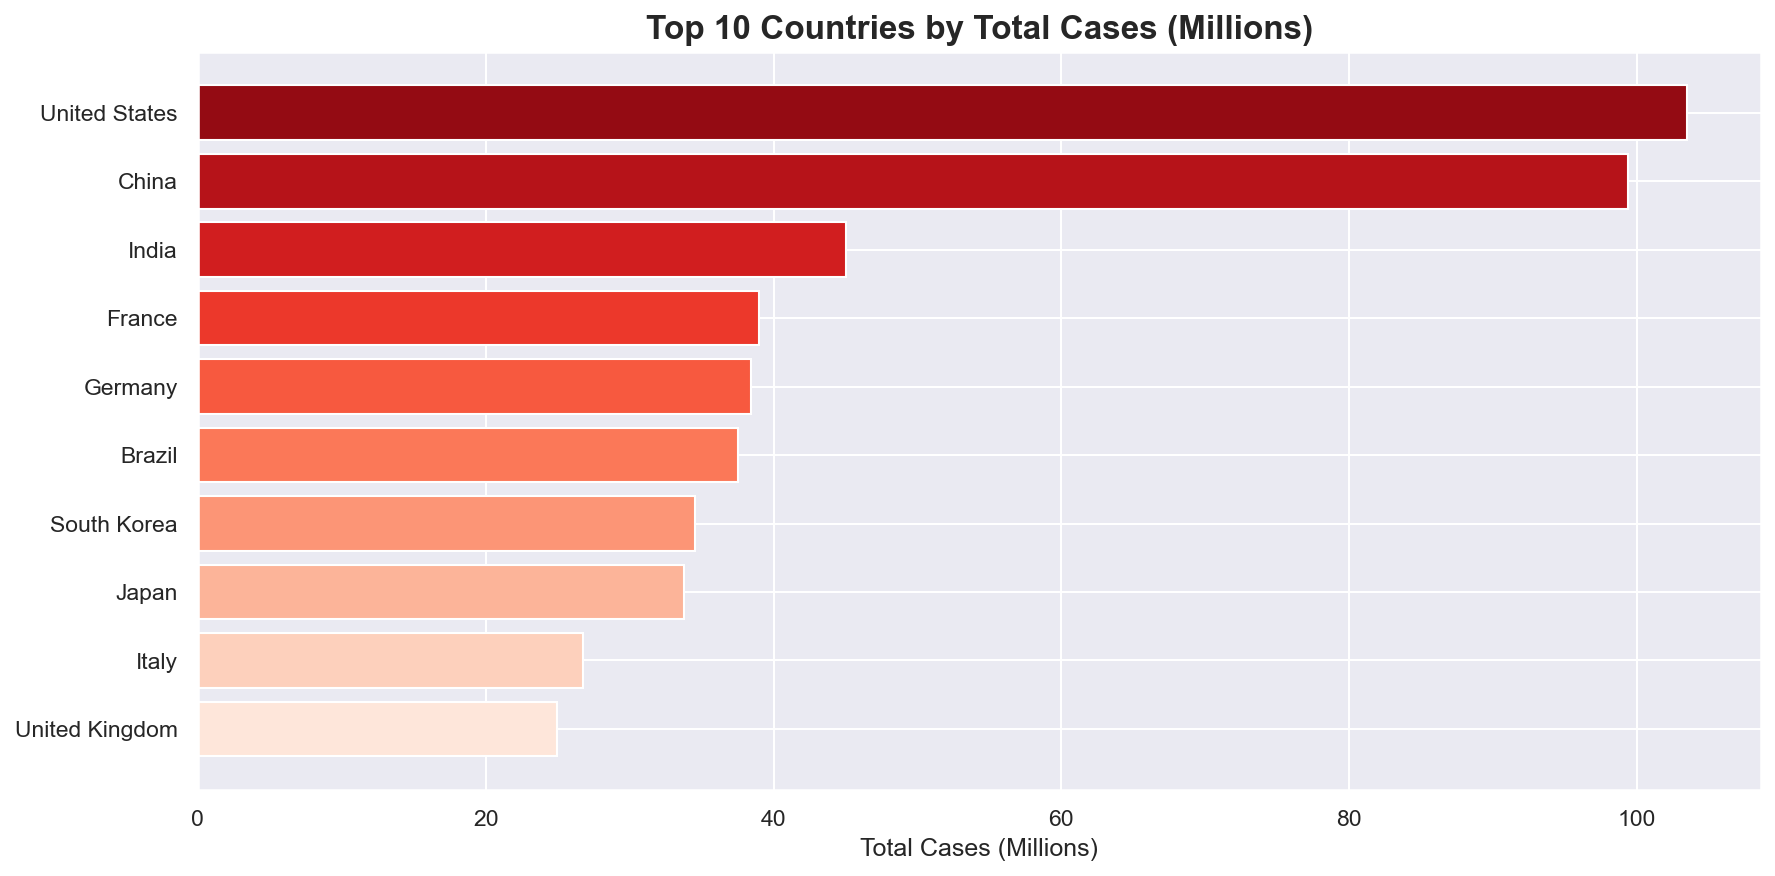

✅ Saved chart2


In [50]:
latest = df.sort_values('date').groupby('location').last().reset_index()
top10_cases = latest.nlargest(10, 'total_cases')[['location', 'total_cases']]

fig, ax = plt.subplots()
bars = ax.barh(top10_cases['location'], top10_cases['total_cases'] / 1e6,
               color=sns.color_palette("Reds_r", 10))
ax.set_title('Top 10 Countries by Total Cases (Millions)', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Cases (Millions)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/chart2_top10_total_cases.png')
plt.show()
print("Saved chart2")

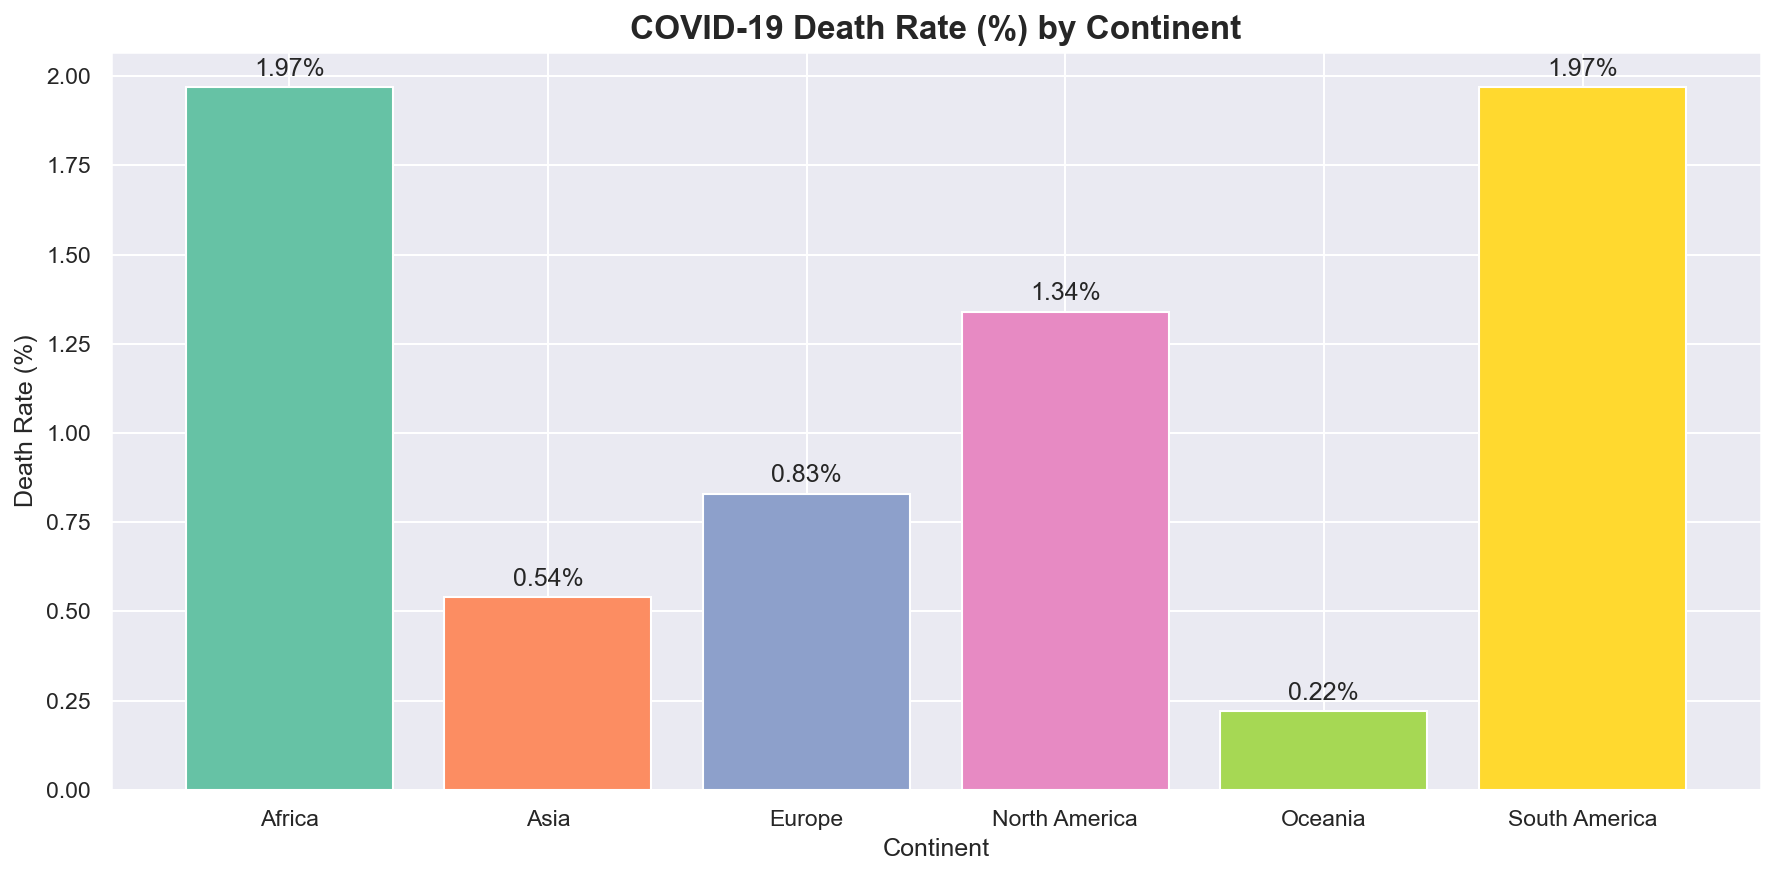

✅ Saved chart3


In [51]:
continent_stats = latest.groupby('continent').agg(
    total_cases=('total_cases', 'sum'),
    total_deaths=('total_deaths', 'sum')
).reset_index()
continent_stats['death_rate'] = (continent_stats['total_deaths'] / 
                                  continent_stats['total_cases'] * 100).round(2)
continent_stats = continent_stats[continent_stats['continent'].notna()]

fig, ax = plt.subplots()
colors = sns.color_palette("Set2", len(continent_stats))
bars = ax.bar(continent_stats['continent'], continent_stats['death_rate'], color=colors)
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_title('COVID-19 Death Rate (%) by Continent', fontsize=16, fontweight='bold')
ax.set_xlabel('Continent')
ax.set_ylabel('Death Rate (%)')
plt.tight_layout()
plt.savefig('visuals/chart3_death_rate_continent.png')
plt.show()
print("Saved chart3")

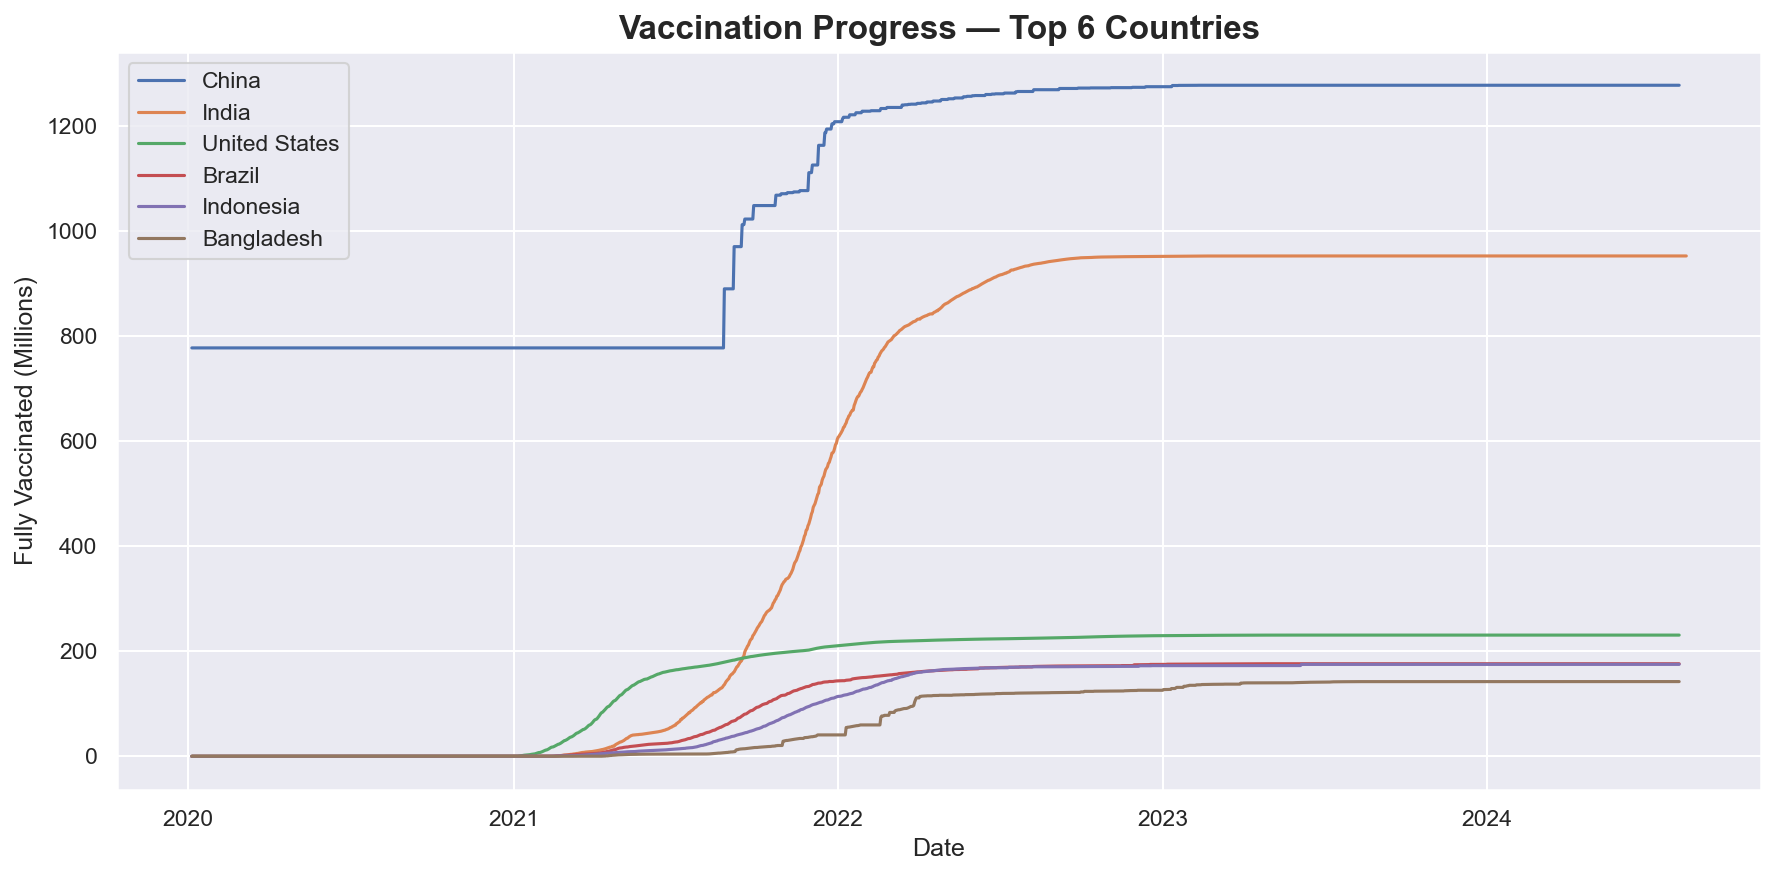

✅ Saved chart4


In [52]:
top6_vax = latest.nlargest(6, 'people_fully_vaccinated')['location'].tolist()
vax_df = df[df['location'].isin(top6_vax)]

fig, ax = plt.subplots()
for country in top6_vax:
    cdf = vax_df[vax_df['location'] == country]
    ax.plot(cdf['date'], cdf['people_fully_vaccinated'] / 1e6, label=country)

ax.set_title('Vaccination Progress — Top 6 Countries', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Fully Vaccinated (Millions)')
ax.legend()
plt.tight_layout()
plt.savefig('visuals/chart4_vaccination_progress.png')
plt.show()
print("Saved chart4")

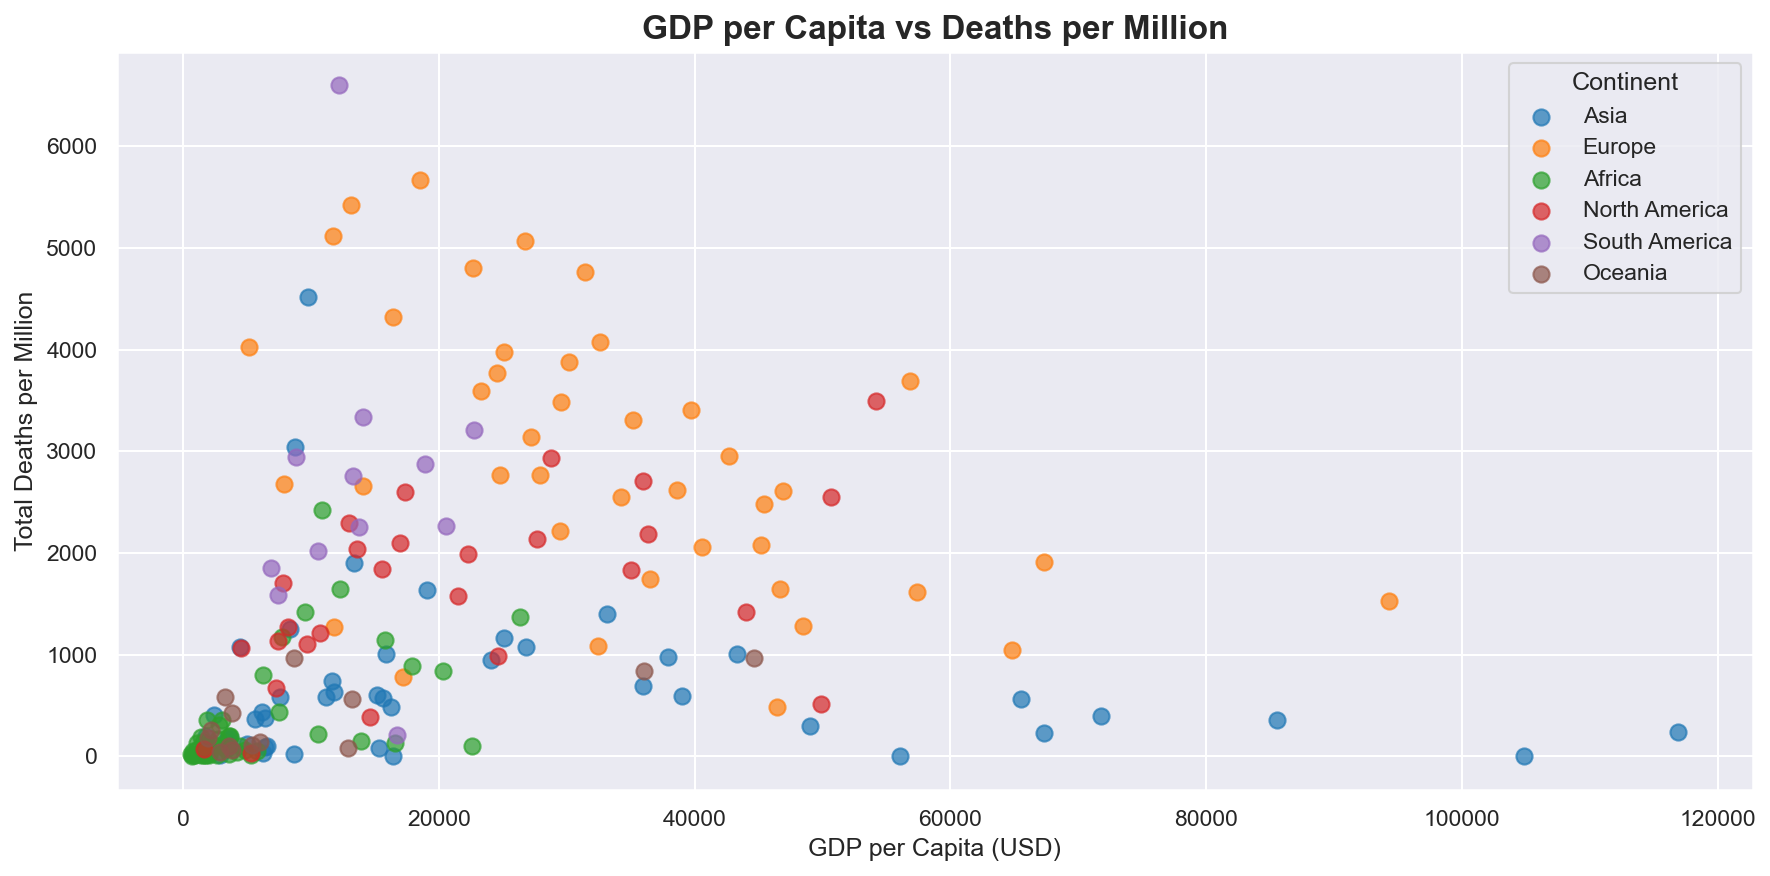

✅ Saved chart5


In [53]:
scatter_df = latest.dropna(subset=['gdp_per_capita', 'total_deaths_per_million', 'continent'])
scatter_df = scatter_df[scatter_df['gdp_per_capita'] > 0]

fig, ax = plt.subplots()
continents = scatter_df['continent'].unique()
palette = sns.color_palette("tab10", len(continents))

for i, cont in enumerate(continents):
    sub = scatter_df[scatter_df['continent'] == cont]
    ax.scatter(sub['gdp_per_capita'], sub['total_deaths_per_million'],
               label=cont, color=palette[i], alpha=0.7, s=60)

ax.set_title('GDP per Capita vs Deaths per Million', fontsize=16, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Total Deaths per Million')
ax.legend(title='Continent')
plt.tight_layout()
plt.savefig('visuals/chart5_gdp_vs_deaths.png')
plt.show()
print("Saved chart5")

In [54]:
df.to_csv('data/covid_cleaned.csv', index=False)
print("Cleaned dataset saved to data/covid_cleaned.csv")
print(f"Final shape: {df.shape}")

✅ Cleaned dataset saved to data/covid_cleaned.csv
Final shape: (395311, 20)
